#Загрузка библиотек

In [ ]:
import numpy as np
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

# Загрузка датасета

In [ ]:
!unzip -q normalized_resized_fracture_dataset.zip

In [ ]:
!ls

normalized_fracture_dataset		 sample_data
normalized_resized_fracture_dataset.zip


In [ ]:
# Статистика ImageNet, если будем использовать предобученные модели
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Трансформации
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(416, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Пути к папкам
root = 'normalized_fracture_dataset'
train_dataset = ImageFolder(f'{root}/train', transform=train_transforms)
val_dataset   = ImageFolder(f'{root}/valid', transform=val_test_transforms)
test_dataset  = ImageFolder(f'{root}/test',  transform=val_test_transforms)

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Предобученные модели

In [ ]:
def get_model(name='resnet18', num_classes=2):
    if name == 'resnet18':
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == 'vgg16':
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif name == 'densenet121':
        model = models.densenet121(pretrained=True)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

# Дисбаланс классов

Взвешенная функция потерь

In [ ]:
# Получаем количество примеров каждого класса
class_counts = [0] * len(train_dataset.classes)
for _, label in train_dataset:
    class_counts[label] += 1

class_weights = [1.0 / count for count in class_counts]
class_weights_tensor = torch.FloatTensor(class_weights).to('cuda')

# Loss с учетом весов
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Обучение

In [ ]:
model = get_model('vgg16').to('cuda')
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Train loss: {total_loss/len(train_loader):.4f}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
def visualize_predictions(model, test_loader, class_names, threshold=0.5, num_images=10):
    model.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to('cuda')
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            pred = torch.argmax(probs, dim=1)

            plt.imshow(images[0].cpu().permute(1, 2, 0).numpy() * imagenet_std + imagenet_mean)
            plt.title(f"Predicted: {class_names[pred.item()]} (Prob: {probs[0][pred.item()]:.2f})\n"
                      f"Actual: {class_names[labels.item()]}")
            plt.axis('off')
            plt.show()

            shown += 1
            if shown >= num_images:
                break

In [ ]:
def evaluate_model(model, dataloader, threshold=0.5):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to('cuda')
            labels = labels.to('cuda')

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)  # softmax: получаем вероятности
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # вероятность класса fracture (обычно метка 1)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)

    print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=train_dataset.classes))
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }


In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer)

Epoch 1, Train loss: 0.7235
Epoch 2, Train loss: 0.6590
Epoch 3, Train loss: 0.5104
Epoch 4, Train loss: 0.3927
Epoch 5, Train loss: 0.3106
Epoch 6, Train loss: 0.2988
Epoch 7, Train loss: 0.2446
Epoch 8, Train loss: 0.2329
Epoch 9, Train loss: 0.1860
Epoch 10, Train loss: 0.1460


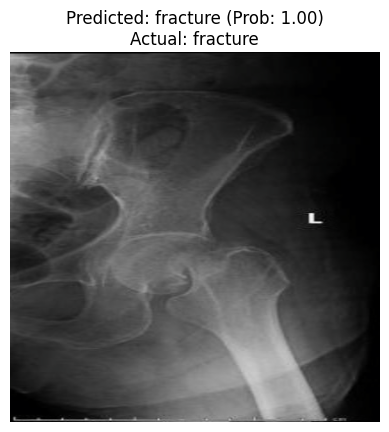

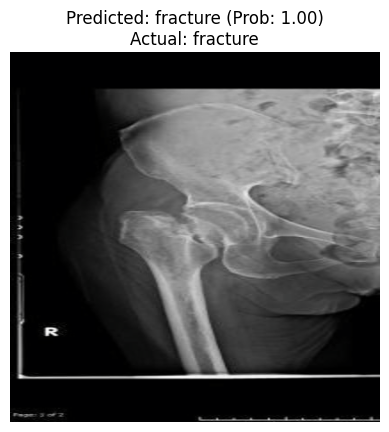

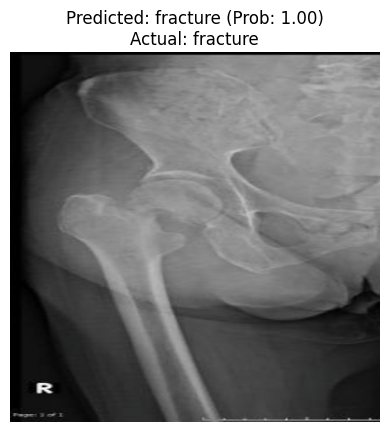

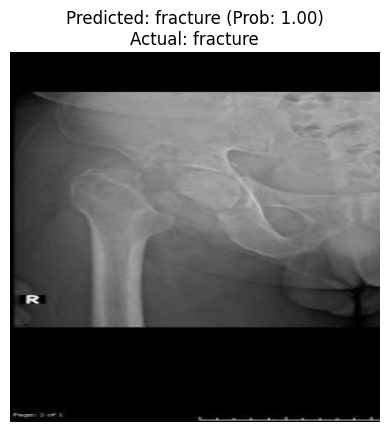

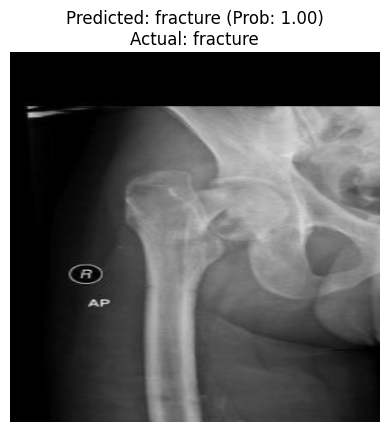

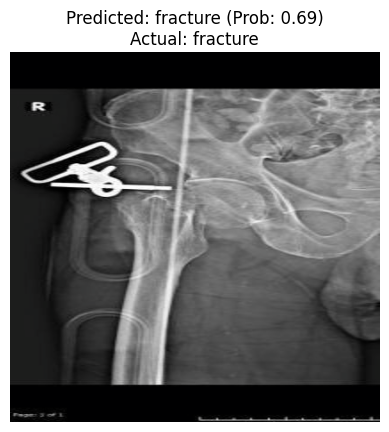

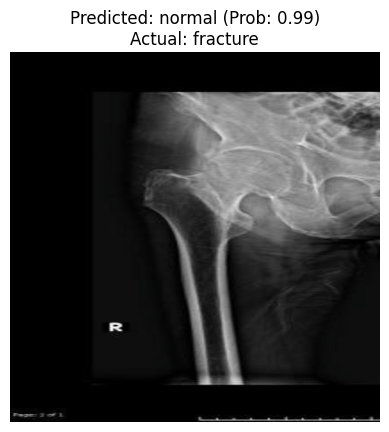

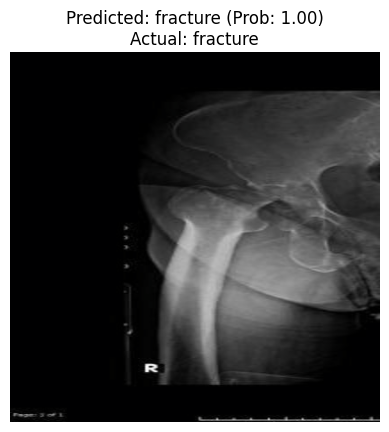

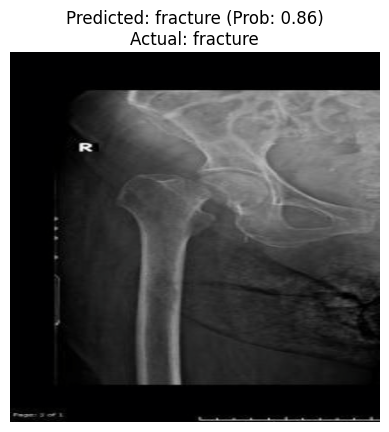

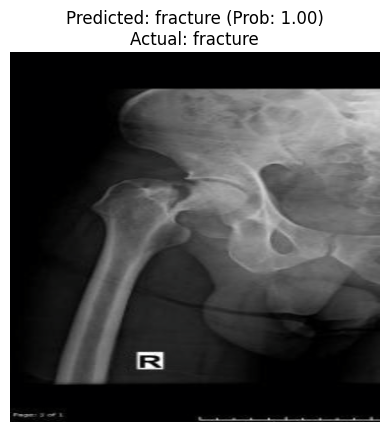

In [ ]:
class_names = train_dataset.classes  # ['fracture', 'normal']

# Визуализировать 10 изображений из теста с порогом 0.5
visualize_predictions(model, test_loader, class_names, threshold=0.5, num_images=10)

In [ ]:
metrics = evaluate_model(model, test_loader)

Classification Report:
               precision    recall  f1-score   support

    fracture       1.00      0.79      0.88        43
      normal       0.93      1.00      0.96       112

    accuracy                           0.94       155
   macro avg       0.96      0.90      0.92       155
weighted avg       0.95      0.94      0.94       155

Accuracy:  0.9419
Precision: 0.9256
Recall:    1.0000
F1-score:  0.9614
AUC:       0.9292
Confusion Matrix:
[[ 34   9]
 [  0 112]]


# Сохранение весов

In [ ]:
# Сохраняем веса модели (state_dict) в файл
torch.save(model.state_dict(), 'hip_fracture_model.pth')

In [ ]:
class_names = train_dataset.classes  # ['fracture', 'normal']

In [ ]:
class_names

['fracture', 'normal']

In [ ]:
train_dataset.classes

['fracture', 'normal']

In [ ]:
print(train_dataset.class_to_idx)

{'fracture': 0, 'normal': 1}


# Модель

In [ ]:
# Импортируй нужную архитектуру (например, ResNet18)
from torchvision import models

# Создай такую же модель
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 класса

# Загрузи веса
model.load_state_dict(torch.load('hip_fracture_model_resnet18.pth'))
model = model.to('cuda')  # если используешь GPU
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_auc(model, test_loader):
    model.eval()
    y_true = []
    y_scores = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probs[:, 1].cpu().numpy())

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


def plot_confidence_histograms(model, test_loader):
    model.eval()
    normal_scores = []
    fracture_scores = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            for p, l in zip(probs[:, 1].cpu().numpy(), labels.cpu().numpy()):
                if l == 0:
                    normal_scores.append(p)
                else:
                    fracture_scores.append(p)

    plt.figure(figsize=(10, 6))
    plt.hist(normal_scores, bins=30, alpha=0.7, label='Normal', color='green')
    plt.hist(fracture_scores, bins=30, alpha=0.7, label='Fracture', color='red')
    plt.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Model Confidence by Class')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fracture'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()


def plot_precision_recall_curve(model, test_loader):
    model.eval()
    y_true = []
    y_scores = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probs[:, 1].cpu().numpy())

    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()


def visualize_predictions(model, test_loader, class_names, num_images=5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to('cuda')
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            img = images[0].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"Predicted: {class_names[preds.item()]}\n"
                      f"Confidence: {probs[0][preds.item()].item():.2f}\n"
                      f"Actual: {class_names[labels.item()]}")
            plt.axis('off')
            plt.show()

            shown += 1
            if shown >= num_images:
                break

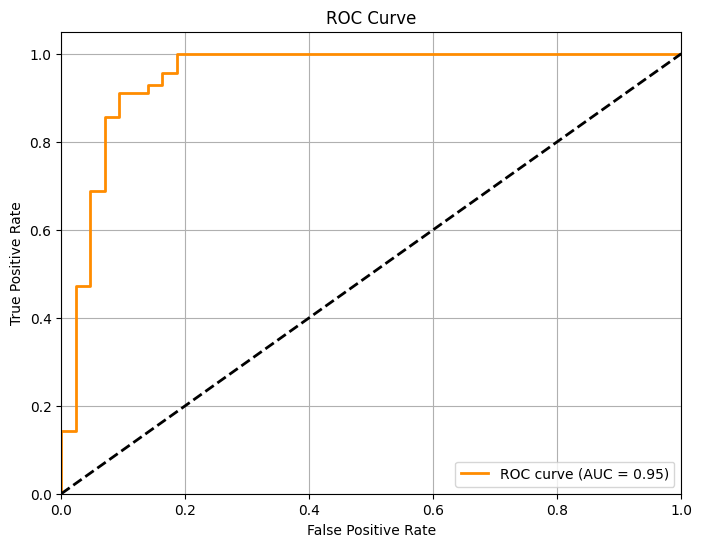

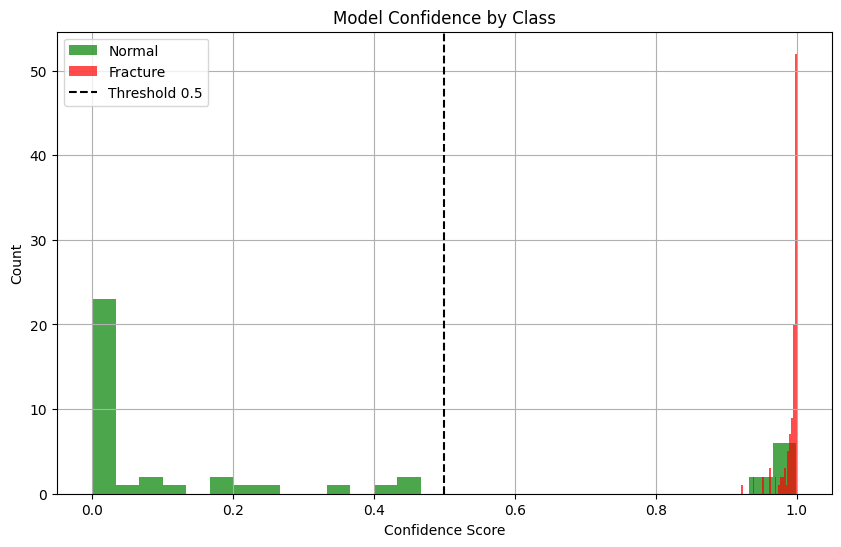

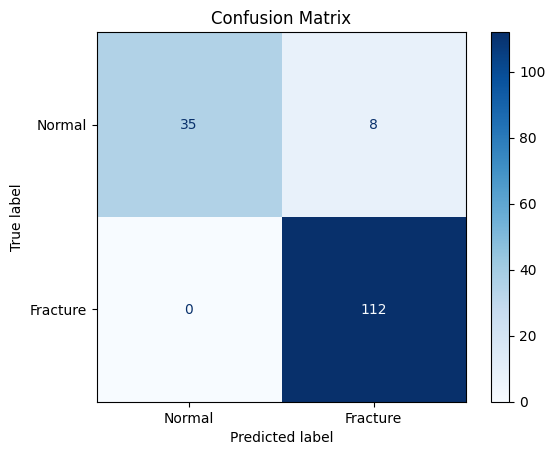

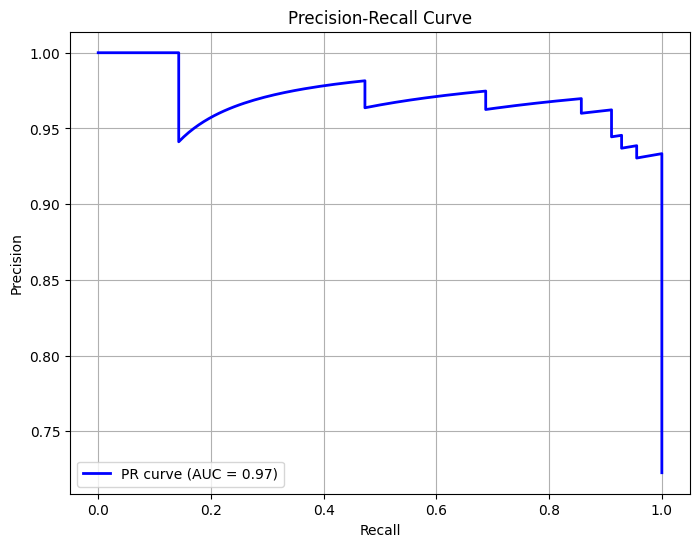

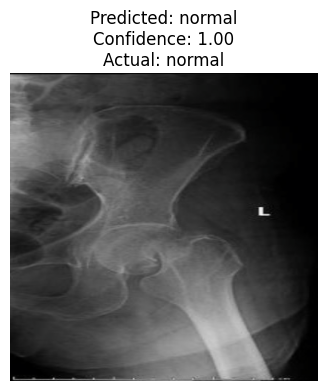

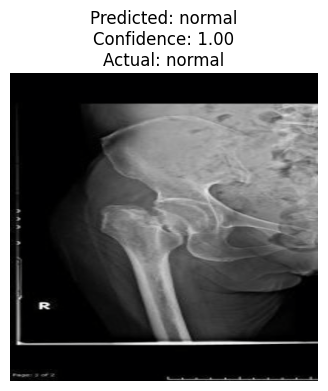

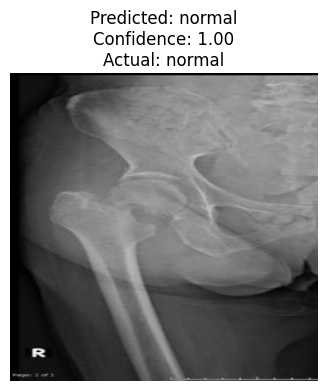

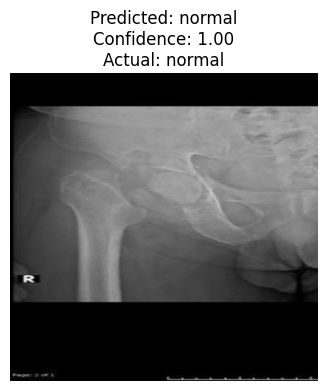

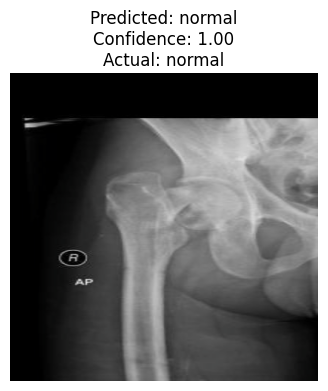

In [ ]:
plot_roc_auc(model, test_loader)
plot_confidence_histograms(model, test_loader)
plot_confusion_matrix(model, test_loader)
plot_precision_recall_curve(model, test_loader)
visualize_predictions(model, test_loader, ['normal', 'fracture'], num_images=5)